<a href="https://colab.research.google.com/github/ferielChaieb/JobAppMobile/blob/main/volatilit%C3%A9Crypto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/crypto-markets.csv")
df_original=df.copy()
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32


In [ ]:
df.shape

(942297, 13)

EDA & Nettoyage

In [ ]:
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32


In [ ]:
df.tail()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
942292,project-x,NANOX,Project-X,2018-11-26,1727,22424.60,23049.30,17607.50,20724.80,143.0,1622.0,0.5728,5441.80
942293,project-x,NANOX,Project-X,2018-11-27,1727,20711.90,23742.10,19292.90,23298.70,637.0,1823.0,0.9003,4449.20
942294,project-x,NANOX,Project-X,2018-11-28,1727,23320.90,25235.10,19888.10,24442.70,49.0,1913.0,0.8518,5347.00
942295,project-x,NANOX,Project-X,2018-11-29,1727,24543.53,24582.47,21457.95,22839.44,153.0,1788.0,0.4421,3124.52
942296,project-x,NANOX,Project-X,2018-11-30,1727,22872.09,23086.98,19040.91,21136.72,125.0,1654.0,0.5180,4046.07


In [ ]:
symbol_counts = df['symbol'].value_counts()
print(symbol_counts)

symbol
BITS    3189
PXC     2123
BTB     2049
BTM     2043
LTC     2042
        ... 
HQT        3
BTNT       2
ATP        2
BCDT       2
BEAT       2
Name: count, Length: 2005, dtype: int64


In [ ]:
print("=== Infos générales ===")
print(df.info())

=== Infos générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942297 entries, 0 to 942296
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   slug         942297 non-null  object 
 1   symbol       942297 non-null  object 
 2   name         942297 non-null  object 
 3   date         942297 non-null  object 
 4   ranknow      942297 non-null  int64  
 5   open         942297 non-null  float64
 6   high         942297 non-null  float64
 7   low          942297 non-null  float64
 8   close        942297 non-null  float64
 9   volume       942297 non-null  float64
 10  market       942297 non-null  float64
 11  close_ratio  942297 non-null  float64
 12  spread       942297 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 93.5+ MB
None


In [ ]:
df.describe()

,ranknow,open,high,low,close,volume,market,close_ratio,spread
count,942297.000000,9.422970e+05,9.422970e+05,9.422970e+05,9.422970e+05,9.422970e+05,9.422970e+05,942297.000000,9.422970e+05
mean,1000.170608,3.483522e+02,4.085930e+02,2.962526e+02,3.461018e+02,8.720383e+06,1.725060e+08,0.459499,1.123400e+02
std,587.575283,1.318436e+04,1.616386e+04,1.092931e+04,1.309822e+04,1.839802e+08,3.575590e+09,0.326160,6.783713e+03
min,1.000000,2.500000e-09,3.200000e-09,2.500000e-10,2.000000e-10,0.000000e+00,0.000000e+00,-1.000000,0.000000e+00
25%,465.000000,2.321000e-03,2.628000e-03,2.044000e-03,2.314000e-03,1.750000e+02,2.958100e+04,0.162900,0.000000e+00
50%,1072.000000,2.398300e-02,2.680200e-02,2.143700e-02,2.389200e-02,4.278000e+03,5.227960e+05,0.432400,0.000000e+00
75%,1484.000000,2.268600e-01,2.508940e-01,2.043910e-01,2.259340e-01,1.190900e+05,6.874647e+06,0.745800,3.000000e-02
max,2072.000000,2.298390e+06,2.926100e+06,2.030590e+06,2.300740e+06,2.384090e+10,3.265025e+11,1.000000,1.770563e+06


In [ ]:
print(df.isnull().sum())

slug           0
symbol         0
name           0
date           0
ranknow        0
open           0
high           0
low            0
close          0
volume         0
market         0
close_ratio    0
spread         0
dtype: int64


In [ ]:
df.isnull()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
942292,False,False,False,False,False,False,False,False,False,False,False,False,False
942293,False,False,False,False,False,False,False,False,False,False,False,False,False
942294,False,False,False,False,False,False,False,False,False,False,False,False,False
942295,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df = df_original.copy()

In [ ]:
print("Avant dropna :", df.shape)
df_clean = df.dropna()
print("Après dropna :", df_clean.shape)

Avant dropna : (942297, 13)
Après dropna : (942297, 13)


In [ ]:
df.isnull().sum()

,0
slug,0
symbol,0
name,0
date,0
ranknow,0
open,0
high,0
low,0
close,0
volume,0


In [ ]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


In [ ]:
df.dtypes

,0
slug,object
symbol,object
name,object
date,object
ranknow,int64
open,float64
high,float64
low,float64
close,float64
volume,float64


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
942292,False
942293,False
942294,False
942295,False


In [ ]:
df.ndim

2

Ingénierie des caractéristiques

In [ ]:
# ============================================
# INGÉNIERIE DES CARACTÉRISTIQUES
# Variables créées depuis les colonnes existantes
# ============================================

# Convertir la date et trier
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date'])

# --- Volatilité (variable cible) ---
# Écart-type du prix de clôture sur 10 jours
df['Volatility'] = df.groupby('symbol')['close'].transform(
    lambda x: x.rolling(10, min_periods=1).std()
)
df['MA_7']  = df.groupby('symbol')['close'].transform(lambda x: x.rolling(7,  min_periods=1).mean())
df['MA_30'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(30, min_periods=1).mean())
# Signal de croisement des deux moyennes
df['MA_signal'] = df['MA_7'] - df['MA_30']

# --- RSI (Relative Strength Index) ---
# Indicateur technique entre 0 et 100
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - (100 / (1 + gain / loss))

df['RSI'] = df.groupby('symbol')['close'].transform(compute_rsi)

# --- Autres indicateurs ---
# Rendement journalier
df['return']       = df.groupby('symbol')['close'].pct_change()
# Amplitude intraday (high - low)
df['daily_range']  = df['high'] - df['low']
# Spread normalisé
df['spread_ratio'] = df['spread'] / df['close']

# Nettoyage — df_clean séparé pour ne pas écraser df
df_clean = df.dropna()

print("df original :", df.shape)
print("df_clean    :", df_clean.shape)
print("Colonnes créées : Volatility, MA_7, MA_30, MA_signal, RSI, return, daily_range, spread_ratio")

df original : (942297, 21)
df_clean    : (913149, 21)
Colonnes créées : Volatility, MA_7, MA_30, MA_signal, RSI, return, daily_range, spread_ratio


In [ ]:
df_model = df.drop(columns=[
    'slug',
    'name',
    'ranknow',
    'close_ratio',
    'return',
    'RSI',
    'MA_signal',
    'daily_range'
])

# Ajoute juste cette ligne
df_model = df_model[df_model['symbol'].isin(['BTC', 'ETH', 'LTC', 'XRP', 'ADA', 'BNB', 'DOGE', 'XLM'])]

print(df_model.shape)


(11546, 13)


Visualisation Avancé

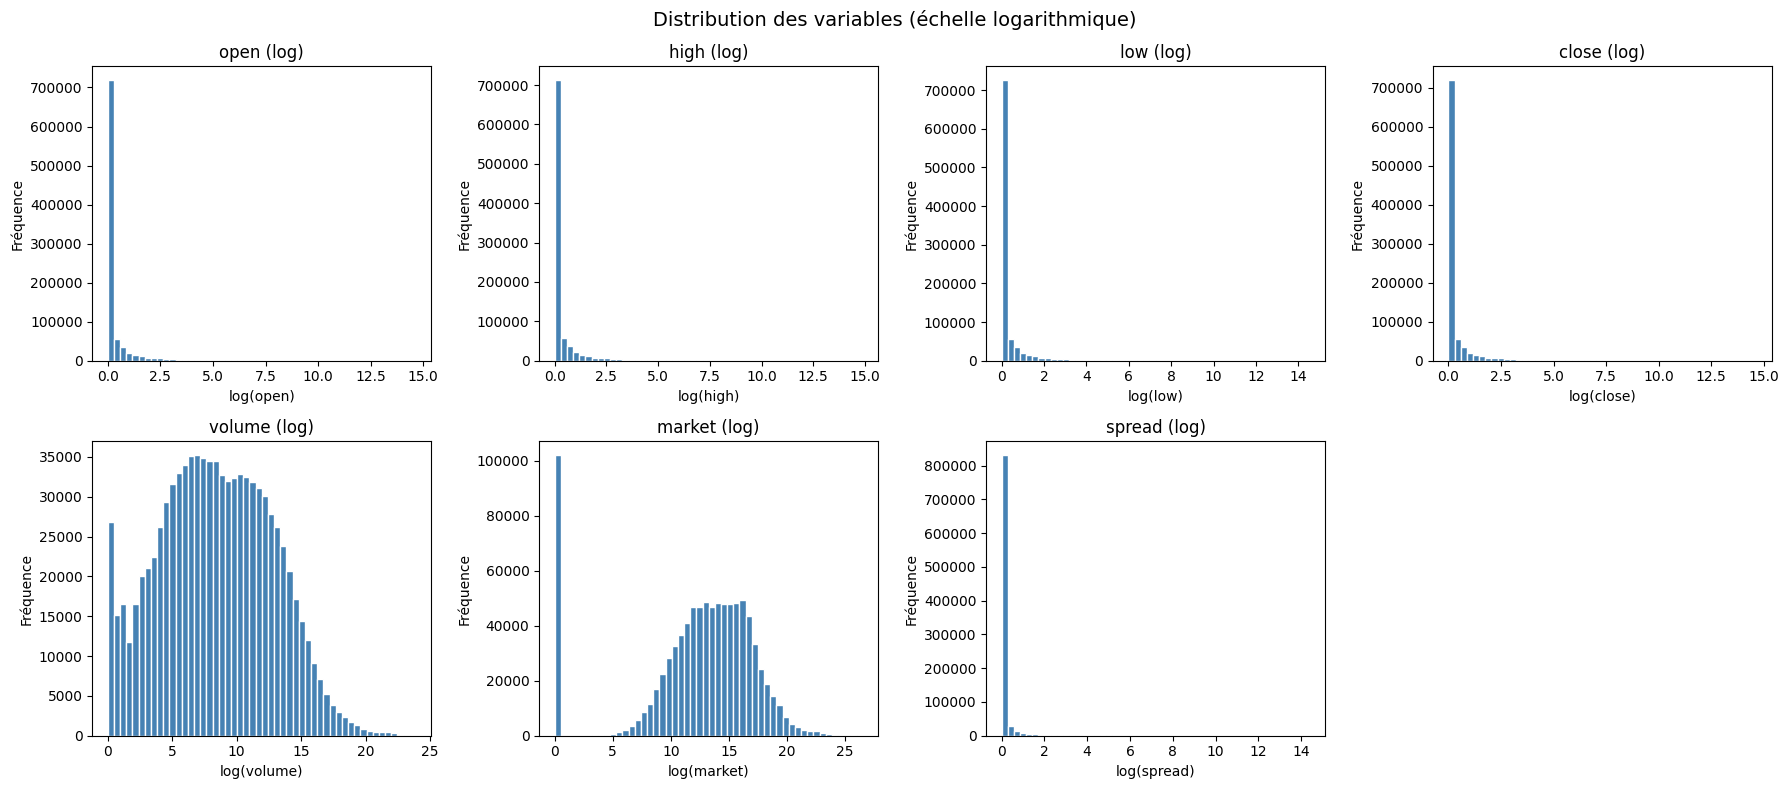

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Variables numériques à analyser
cols_num = ['open', 'high', 'low', 'close', 'volume', 'market', 'spread']

# Création de la figure
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# Histogrammes avec transformation log
for i, col in enumerate(cols_num):
    data = df_clean[col].dropna()

    # Sécurité : éviter les valeurs négatives
    data = data[data >= 0]

    # Transformation logarithmique
    data_log = np.log1p(data)

    axes[i].hist(data_log, bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f"{col} (log)")
    axes[i].set_xlabel(f"log({col})")
    axes[i].set_ylabel("Fréquence")

# Cacher les cases vides
for j in range(len(cols_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables (échelle logarithmique)", fontsize=14)
plt.tight_layout()
plt.show()

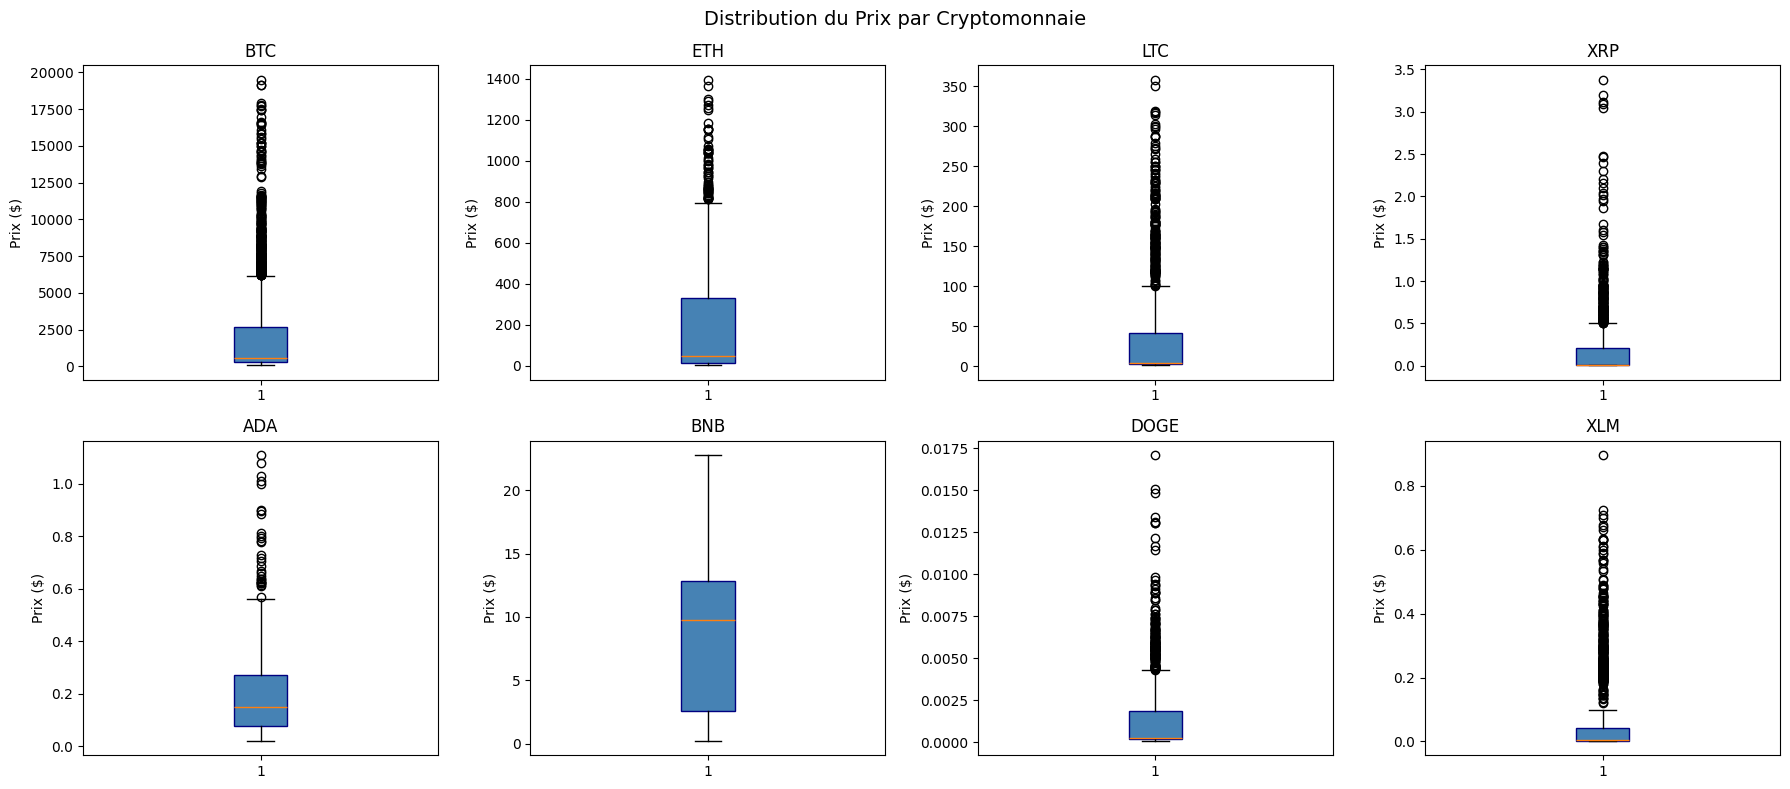

In [ ]:
# ✅ Un subplot par crypto — chaque échelle est indépendante
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, crypto in zip(axes.flatten(),
                      ['BTC','ETH','LTC','XRP','ADA','BNB','DOGE','XLM']):
    data = df_clean[df_clean['symbol'] == crypto]['close']
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='navy'))
    ax.set_title(crypto)
    ax.set_ylabel("Prix ($)")

plt.suptitle("Distribution du Prix par Cryptomonnaie", fontsize=14)
plt.tight_layout()
plt.show()

# CORRÉLATION ENTRE DIFFÉRENTS ACTIFS

symbol   ADA   BNB   BTC  DOGE   ETH   LTC   XLM   XRP
symbol                                                
ADA     1.00  0.44  0.72  0.82  0.89  0.80  0.87  0.95
BNB     0.44  1.00  0.29  0.59  0.47  0.34  0.78  0.51
BTC     0.72  0.29  1.00  0.87  0.91  0.95  0.86  0.86
DOGE    0.82  0.59  0.87  1.00  0.86  0.87  0.91  0.93
ETH     0.89  0.47  0.91  0.86  1.00  0.94  0.89  0.89
LTC     0.80  0.34  0.95  0.87  0.94  1.00  0.85  0.89
XLM     0.87  0.78  0.86  0.91  0.89  0.85  1.00  0.92
XRP     0.95  0.51  0.86  0.93  0.89  0.89  0.92  1.00


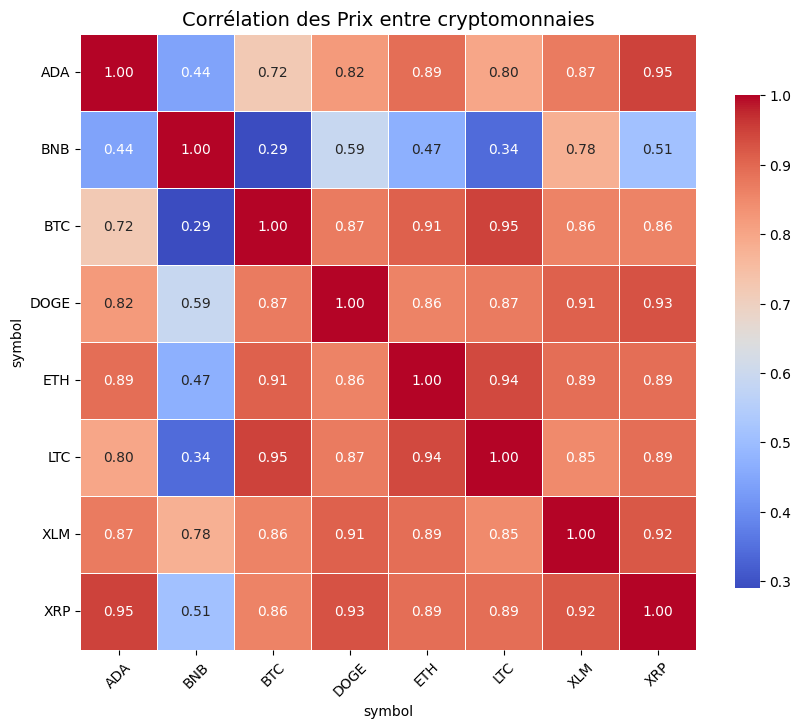

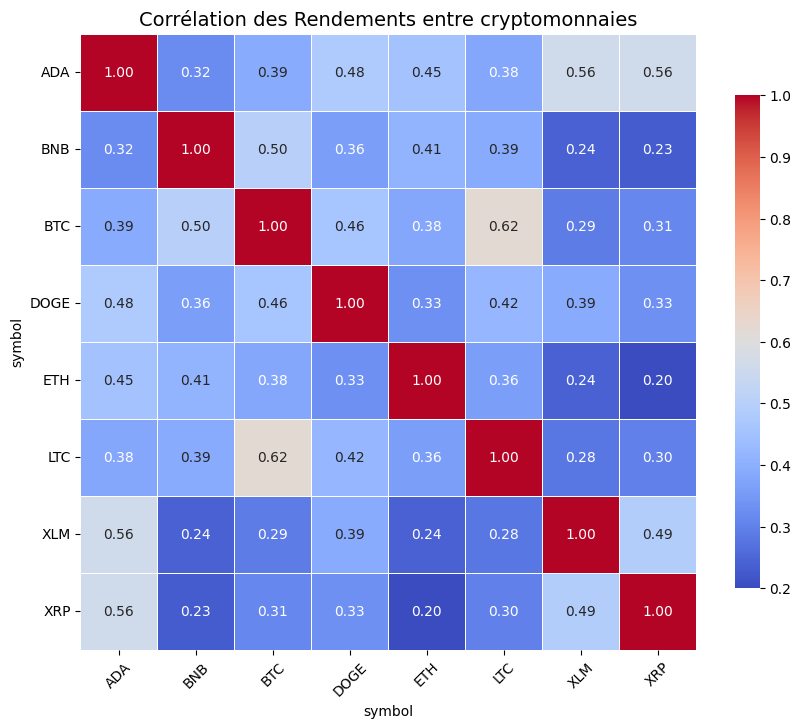

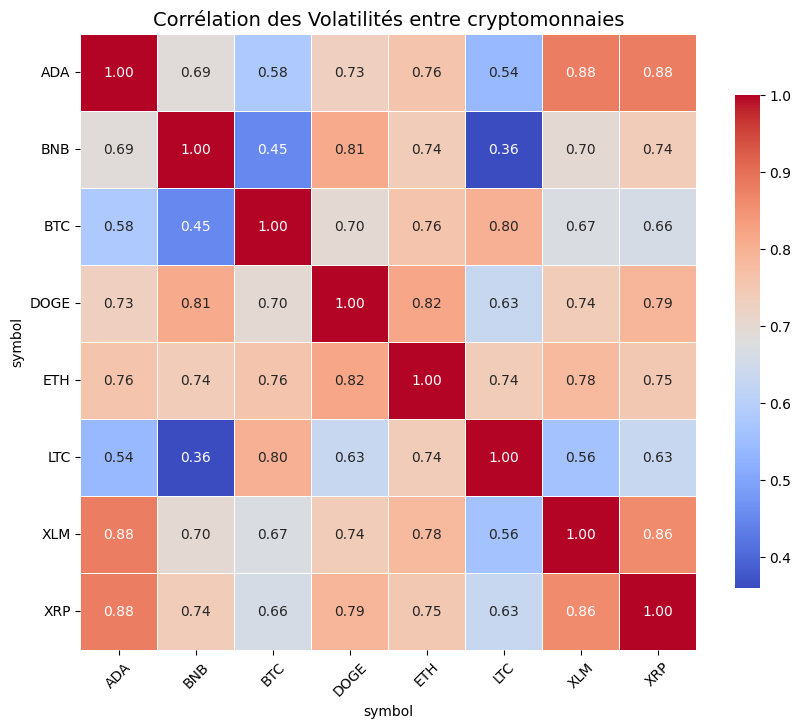

In [ ]:
# ============================================
# CORRÉLATION ENTRE DIFFÉRENTS ACTIFS
# ============================================

# Choisir les cryptos à analyser
cryptos = ['BTC', 'ETH', 'LTC', 'XRP', 'ADA', 'BNB', 'DOGE', 'XLM']

# Filtrer les données
df_selected = df_clean[df_clean['symbol'].isin(cryptos)].copy()

# Convertir la date
df_selected['date'] = pd.to_datetime(df_selected['date'])

# ---- Corrélation des PRIX ----
df_pivot = df_selected.pivot(index='date', columns='symbol', values='close')
corr_assets = df_pivot.corr().round(2)
print(corr_assets)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_assets,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Corrélation des Prix entre cryptomonnaies", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# ---- Corrélation des RENDEMENTS ----
df_return = df_pivot.pct_change(fill_method=None)
corr_return = df_return.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_return,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Corrélation des Rendements entre cryptomonnaies", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# ---- Corrélation des VOLATILITÉS ----
df_vol = df_selected.pivot(index='date', columns='symbol', values='Volatility')
corr_vol = df_vol.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_vol,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Corrélation des Volatilités entre cryptomonnaies", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Variables influençant la Volatilité des cryptomonnaies

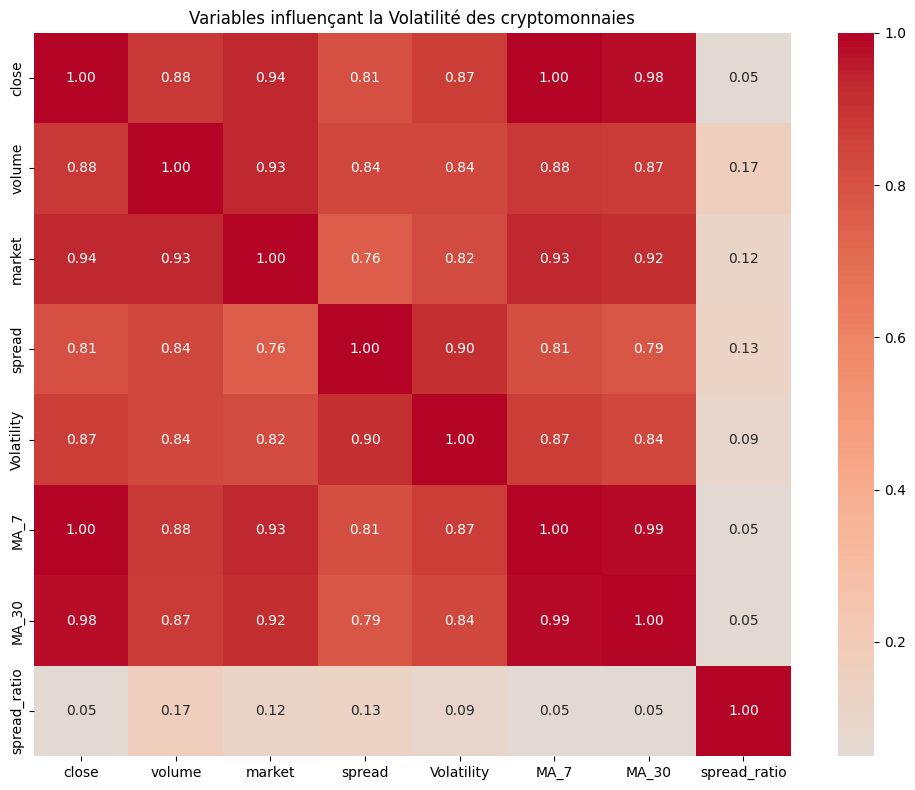

In [ ]:
# ============================================
# HEATMAP FINALE ENRICHIE
# ============================================

# ✅ Filtrer explicitement sur les 8 cryptos
cryptos_main = ['BTC', 'ETH', 'LTC', 'XRP',
                'ADA', 'BNB', 'DOGE', 'XLM']

df_clean_filtre = df_clean[df_clean['symbol'].isin(cryptos_main)]

cols = ['close', 'volume', 'market', 'spread',
        'Volatility', 'MA_7', 'MA_30', 'spread_ratio']

corr_final = df_clean_filtre[cols].corr()  # ← filtré !

plt.figure(figsize=(10, 8))
sns.heatmap(corr_final, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title("Variables influençant la Volatilité des cryptomonnaies")
plt.tight_layout()
plt.show()

Quelles variables influencent la Volatilité ?

Variable           Pearson   Spearman
--------------------------------------
open                 0.871      0.984
high                 0.878      0.984
low                  0.859      0.983
close                0.872      0.984
volume               0.844      0.686
market               0.818      0.795
spread               0.904      0.966
MA_7                 0.870      0.983
MA_30                0.843      0.981
spread_ratio         0.093      0.710


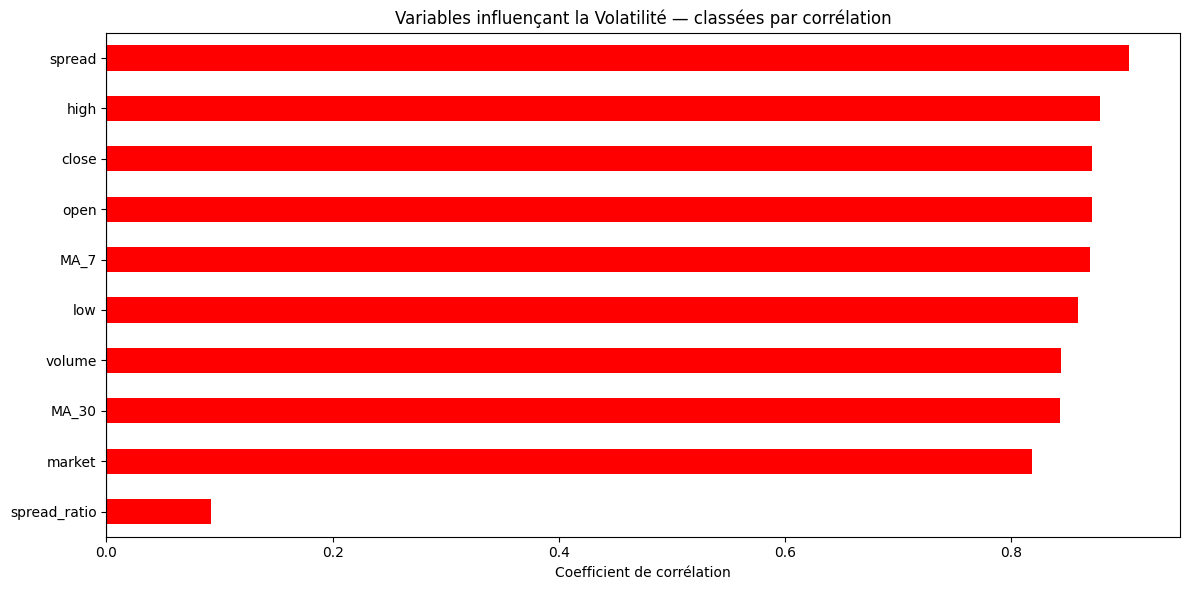

In [ ]:
# ============================================
# RÉPONSE À LA PROBLÉMATIQUE :
# Quelles variables influencent la Volatilité ?
# ============================================

from scipy.stats import pearsonr, spearmanr

# ✅ Uniquement les colonnes qui existent dans df_clean_filtre
variables = ['open', 'high', 'low', 'close', 'volume', 'market',
             'spread', 'MA_7', 'MA_30', 'spread_ratio']
#  ❌ Supprimées : close_ratio, return, daily_range, MA_signal, RSI

# Tableau Pearson + Spearman
print(f"{'Variable':<15} {'Pearson':>10} {'Spearman':>10}")
print("-" * 38)
for col in variables:
    p_corr, _ = pearsonr(df_clean_filtre[col],  df_clean_filtre['Volatility'])
    s_corr, _ = spearmanr(df_clean_filtre[col], df_clean_filtre['Volatility'])
    print(f"{col:<15} {p_corr:>10.3f} {s_corr:>10.3f}")

# Barplot
corr_vol = df_clean_filtre[variables + ['Volatility']].corr()['Volatility'].drop('Volatility').sort_values()

plt.figure(figsize=(12, 6))
colors = ['red' if x > 0 else 'blue' for x in corr_vol]
corr_vol.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Variables influençant la Volatilité — classées par corrélation")
plt.xlabel("Coefficient de corrélation")
plt.tight_layout()
plt.show()

(11546, 13)


In [ ]:
# ============================================
# MODELE 1 — Colonnes originales seulement
# ============================================
features_v1 = ['open', 'high', 'low', 'volume', 'market', 'spread']
target = 'Volatility'

df_model1 = df_model.dropna(subset=features_v1 + [target])
print(df_model1.shape)

(11538, 13)


 SCATTER PLOTS — RELATIONS VARIABLES / VOLATILITÉ

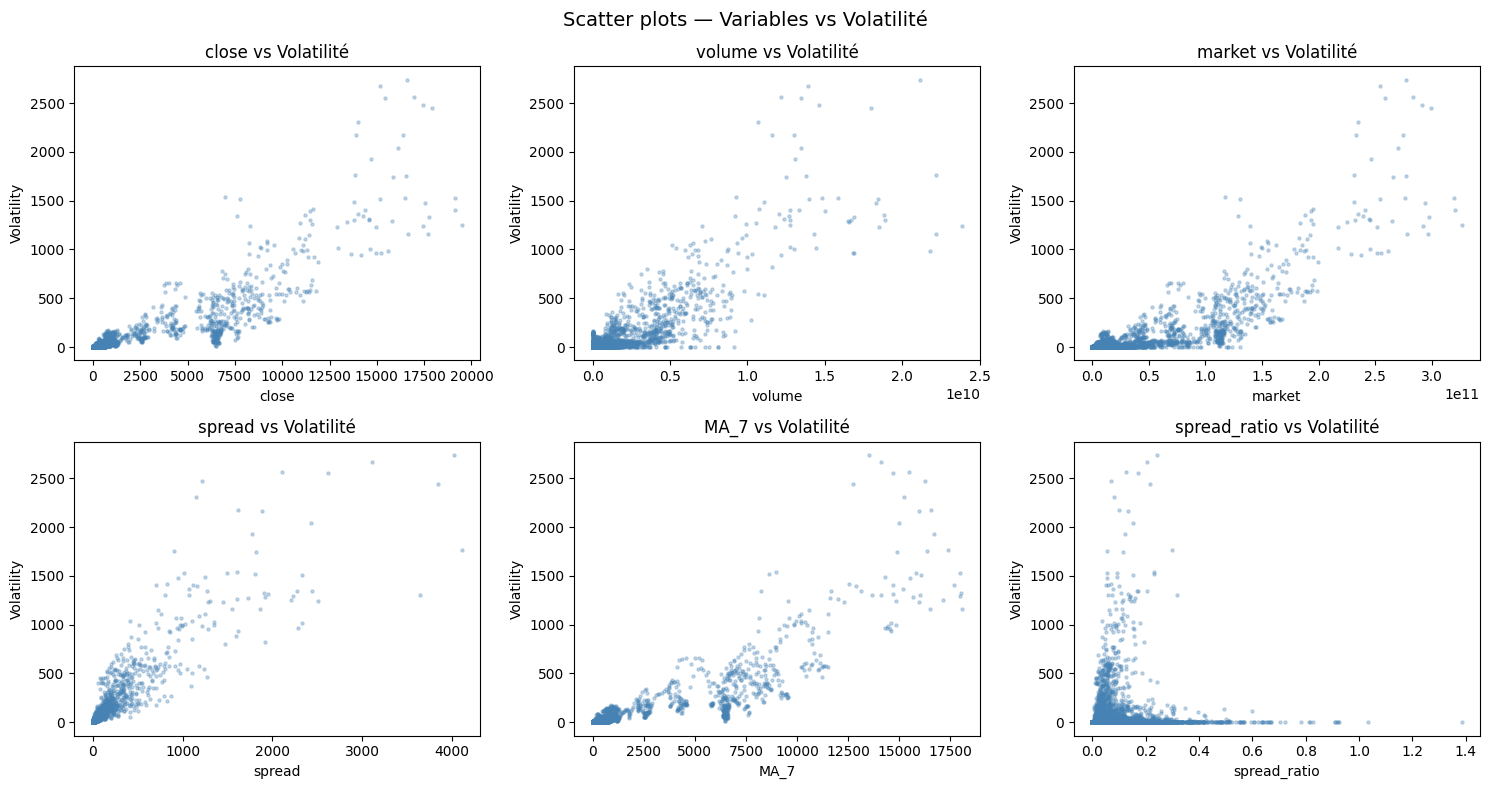

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ✅ daily_range supprimée → remplacée par spread_ratio
pairs = [('close',        'Volatility'),
         ('volume',       'Volatility'),
         ('market',       'Volatility'),
         ('spread',       'Volatility'),
         ('MA_7',         'Volatility'),   # ← remplace daily_range
         ('spread_ratio', 'Volatility'),   # ← 6ème graphique bonus
         ]

for ax, (x, y) in zip(axes.flatten(), pairs):
    ax.scatter(df_clean_filtre[x], df_clean_filtre[y],
               alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs Volatilité")

plt.suptitle("Scatter plots — Variables vs Volatilité", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# MODELE 1 : Colonnes originales seulement
# ============================================

In [ ]:
features_v1 = ['open','high','low','volume','market','spread']
target = 'Volatility'

df_model1 = df_model.dropna(subset=features_v1 + [target])
X1 = df_model1[features_v1]
y1 = df_model1[target]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
scaler1 = StandardScaler()
X1_train = scaler1.fit_transform(X1_train)
X1_test  = scaler1.transform(X1_test)

lr1 = LinearRegression().fit(X1_train, y1_train)
rf1 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X1_train, y1_train)
y1_pred_lr = lr1.predict(X1_test)
y1_pred_rf = rf1.predict(X1_test)

# ============================================
# MODELE 2 : + Feature Engineering
# Meilleur modèle car plus d'information
# ============================================

In [ ]:
# ============================================
# MODELE 2 — + Feature Engineering
# ============================================

# ✅ daily_range retiré — redondant avec spread
features_v2 = ['open', 'high', 'low', 'volume', 'market',
               'spread', 'MA_7', 'MA_30', 'spread_ratio']

df_model2 = df_model.dropna(subset=features_v2 + [target])
X2 = df_model2[features_v2]
y2 = df_model2[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)

lr2 = LinearRegression().fit(X2_train, y2_train)
rf2 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X2_train, y2_train)
y2_pred_lr = lr2.predict(X2_test)
y2_pred_rf = rf2.predict(X2_test)

In [ ]:
# ============================================
# ÉVALUATION COMPLÈTE ET COMPARAISON
# ============================================

# Tableau comparatif
resultats = pd.DataFrame({
    'Modèle' : ['LR-Original','RF-Original',
                 'LR-Enrichi', 'RF-Enrichi'],
    'MAE'    : [mean_absolute_error(y1_test, y1_pred_lr),
                mean_absolute_error(y1_test, y1_pred_rf),
                mean_absolute_error(y2_test, y2_pred_lr),
                mean_absolute_error(y2_test, y2_pred_rf)],
    'RMSE'   : [np.sqrt(mean_squared_error(y1_test, y1_pred_lr)),
                np.sqrt(mean_squared_error(y1_test, y1_pred_rf)),
                np.sqrt(mean_squared_error(y2_test, y2_pred_lr)),
                np.sqrt(mean_squared_error(y2_test, y2_pred_rf))],
    'R2'     : [r2_score(y1_test, y1_pred_lr),
                r2_score(y1_test, y1_pred_rf),
                r2_score(y2_test, y2_pred_lr),
                r2_score(y2_test, y2_pred_rf)]
})
print(resultats)



        Modèle        MAE       RMSE        R2
0  LR-Original  10.711196  46.397457  0.880438
1  RF-Original   8.608164  47.455124  0.874924
2   LR-Enrichi  10.746847  49.008076  0.866604
3   RF-Enrichi   6.577760  33.429958  0.937931


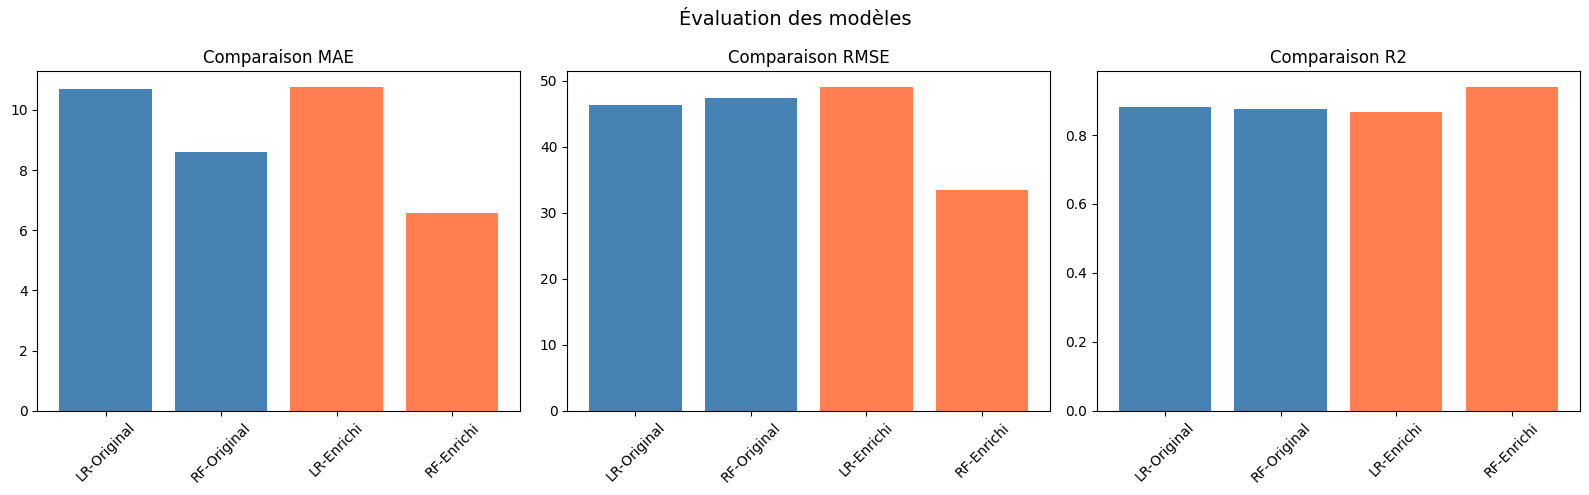

In [ ]:
# Graphiques comparaison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue','steelblue','coral','coral']

for ax, metric in zip(axes, ['MAE','RMSE','R2']):
    ax.bar(resultats['Modèle'], resultats[metric], color=colors)
    ax.set_title(f"Comparaison {metric}")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Évaluation des modèles", fontsize=14)
plt.tight_layout()
plt.show()



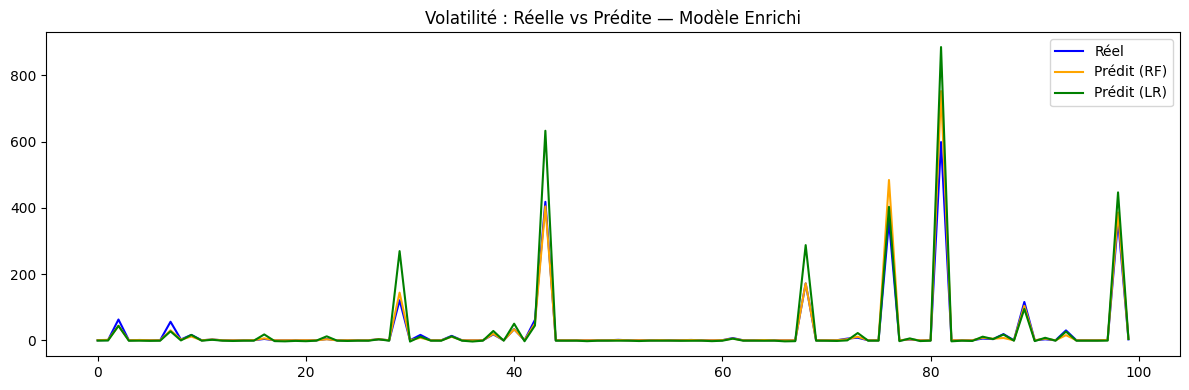

In [ ]:
# Réel vs Prédit
plt.figure(figsize=(12, 4))
plt.plot(y2_test.values[:100], label='Réel',       color='blue')
plt.plot(y2_pred_rf[:100],     label='Prédit (RF)', color='orange')
plt.plot(y2_pred_lr[:100],     label='Prédit (LR)', color='green')
plt.title("Volatilité : Réelle vs Prédite — Modèle Enrichi")
plt.legend()
plt.tight_layout()
plt.show()



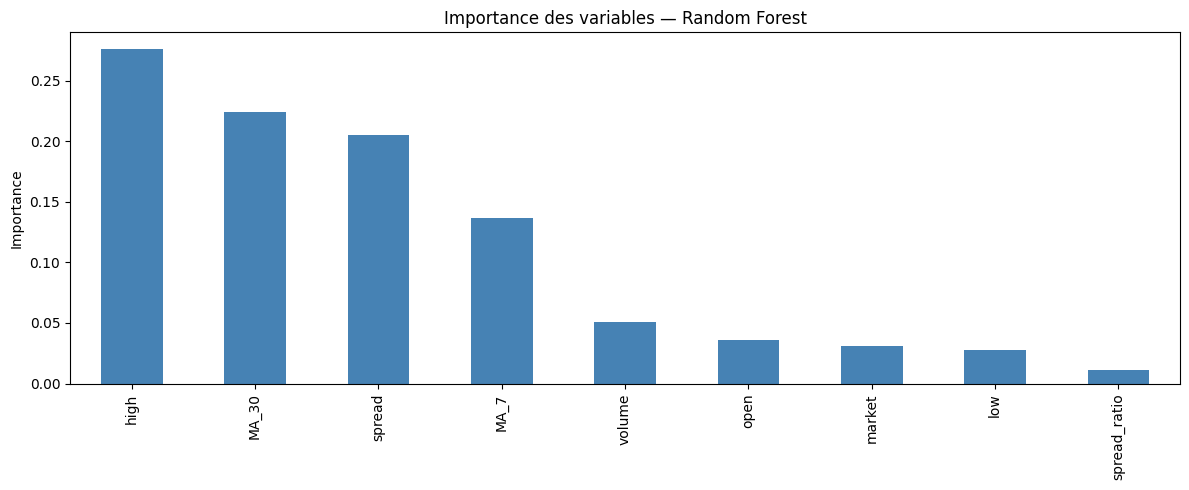

In [ ]:
# Feature Importance
importances = pd.Series(
    rf2.feature_importances_, index=features_v2
).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar', color='steelblue')
plt.title("Importance des variables — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [2]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.1 MB/s eta 0:00:00


In [3]:
from pyngrok import ngrok

# Colle ton token ici
ngrok.set_auth_token("3Cy8Mnz7QQ44oZB4wv6taygSyRi_5B9TYhPHMMdykpxFSMaz3")

In [4]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# CONFIGURATION
# ============================================
st.set_page_config(
    page_title="Crypto Dashboard",
    page_icon="📈",
    layout="wide"
)

# ============================================
# CRYPTOS PRINCIPALES (cohérent avec le notebook)
# ============================================
CRYPTOS_MAIN = ['BTC', 'ETH', 'LTC', 'XRP', 'ADA', 'BNB', 'DOGE', 'XLM']

# ============================================
# FEATURES (colonnes supprimées exclues)
# ✅ slug, name, ranknow, close_ratio, return, RSI, MA_signal → supprimés
# ============================================
FEATURES_V1 = ['open', 'high', 'low', 'volume', 'market', 'spread']

FEATURES_V2 = ['open', 'high', 'low', 'volume', 'market',
               'spread', 'MA_7', 'MA_30', 'daily_range', 'spread_ratio']

TARGET = 'Volatility'

# ============================================
# CHARGEMENT & FEATURE ENGINEERING
# ============================================
@st.cache_data
def load_data():
    # ✅ Correction : chemin flexible
    try:
        df = pd.read_csv("/content/drive/MyDrive/crypto-markets.csv")
    except FileNotFoundError:
        df = pd.read_csv("crypto-markets.csv")

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['symbol', 'date'])

    # --- Feature Engineering ---
    def compute_rsi(series, period=14):
        delta = series.diff()
        gain  = delta.clip(lower=0).rolling(period).mean()
        loss  = (-delta.clip(upper=0)).rolling(period).mean()
        return 100 - (100 / (1 + gain / loss))

    df['Volatility']   = df.groupby('symbol')['close'].transform(
                            lambda x: x.rolling(10, min_periods=1).std())
    df['MA_7']         = df.groupby('symbol')['close'].transform(
                            lambda x: x.rolling(7,  min_periods=1).mean())
    df['MA_30']        = df.groupby('symbol')['close'].transform(
                            lambda x: x.rolling(30, min_periods=1).mean())
    df['MA_signal']    = df['MA_7'] - df['MA_30']
    df['RSI']          = df.groupby('symbol')['close'].transform(compute_rsi)
    df['return']       = df.groupby('symbol')['close'].pct_change()
    df['daily_range']  = df['high'] - df['low']
    df['spread_ratio'] = df['spread'] / df['close']

    return df  # ✅ Correction indentation

df = load_data()

# ============================================
# TITRE
# ============================================
st.title("📈 Analyse de la Volatilité des Cryptomonnaies")
st.markdown("**Problématique** : Quelles variables influencent la volatilité ?")

# ============================================
# SIDEBAR
# ============================================
st.sidebar.title("🔧 Filtres")

cryptos = st.sidebar.multiselect(
    "Choisir les cryptos",
    options=CRYPTOS_MAIN,
    default=['BTC', 'ETH', 'LTC']
)

date_min = st.sidebar.date_input("Date début", df['date'].min())
date_max = st.sidebar.date_input("Date fin",   df['date'].max())

df_filtered = df[
    (df['symbol'].isin(cryptos)) &
    (df['date'] >= pd.to_datetime(date_min)) &
    (df['date'] <= pd.to_datetime(date_max))
].copy()

# ============================================
# ONGLETS
# ============================================
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📊 Exploration",
    "📉 Distribution",
    "🔥 Corrélation",
    "📈 Visualisation",
    "🤖 Prédiction"
])

# ---- ONGLET 1 : Exploration ----
with tab1:
    st.subheader("Aperçu des données")

    col1, col2, col3 = st.columns(3)
    col1.metric("Lignes totales",   df.shape[0])
    col2.metric("Cryptos choisies", len(cryptos))
    col3.metric("Colonnes",         df.shape[1])

    st.dataframe(df_filtered.head(50))

    st.subheader("Statistiques descriptives")
    st.dataframe(df_filtered.describe())

# ---- ONGLET 2 : Distribution ----
with tab2:
    st.subheader("Distribution des variables")

    col = st.selectbox("Choisir une variable",
                       ['open', 'high', 'low', 'close', 'volume', 'market', 'spread'])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_filtered[col], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].set_title(f"Histogramme — {col}")

    axes[1].boxplot(df_filtered[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'))
    axes[1].set_title(f"Boxplot — {col}")

    plt.tight_layout()
    st.pyplot(fig)

# ---- ONGLET 3 : Corrélation ----
with tab3:
    st.subheader("Matrice de Corrélation")

    # ✅ Correction : uniquement les colonnes gardées dans le modèle
    cols_corr = ['close', 'volume', 'market', 'spread',
                 TARGET, 'daily_range', 'MA_7', 'MA_30', 'spread_ratio']

    corr = df_filtered[cols_corr].dropna().corr().round(2)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm',
                linewidths=0.5, fmt=".2f", square=True,
                cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title("Variables influençant la Volatilité", fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    st.pyplot(fig)

    st.subheader("Influence sur la Volatilité")
    corr_vol = corr[TARGET].drop(TARGET).sort_values()

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    colors = ['red' if x > 0 else 'blue' for x in corr_vol]
    corr_vol.plot(kind='barh', color=colors, ax=ax2)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_title("Variables classées par corrélation avec Volatilité")
    st.pyplot(fig2)

# ---- ONGLET 4 : Visualisation ----
with tab4:
    st.subheader("Évolution du Prix et Moyennes Mobiles")

    for crypto in cryptos:
        df_c = df_filtered[df_filtered['symbol'] == crypto]
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(df_c['date'], df_c['close'], label='Close', color='blue')
        ax.plot(df_c['date'], df_c['MA_7'],  label='MA_7',  color='orange')
        ax.plot(df_c['date'], df_c['MA_30'], label='MA_30', color='green')
        ax.set_title(f"{crypto} — Prix et Moyennes Mobiles")
        ax.legend()
        st.pyplot(fig)

    st.subheader("Volatilité dans le temps")
    fig3, ax3 = plt.subplots(figsize=(12, 4))
    for crypto in cryptos:
        df_c = df_filtered[df_filtered['symbol'] == crypto]
        ax3.plot(df_c['date'], df_c[TARGET], label=crypto)
    ax3.set_title("Volatilité par crypto")
    ax3.legend()
    st.pyplot(fig3)

# ---- ONGLET 5 : Prédiction ----  ✅ Correction indentation
with tab5:
    st.subheader("🤖 Prédiction de la Volatilité")

    # ============================================
    # ENTRAÎNEMENT — cohérent avec le notebook
    # ✅ Filtre sur les 8 cryptos principales
    # ✅ Deux modèles : Original vs Enrichi
    # ✅ Colonnes supprimées exclues des features
    # ============================================
    @st.cache_resource
    def train_models(df):
        # Filtrer sur les 8 cryptos principales (comme dans le notebook)
        df_ml = df[df['symbol'].isin(CRYPTOS_MAIN)].copy()

        # --- Modèle 1 : colonnes originales ---
        df_m1 = df_ml.dropna(subset=FEATURES_V1 + [TARGET])
        X1 = df_m1[FEATURES_V1]
        y1 = df_m1[TARGET]
        X1_train, X1_test, y1_train, y1_test = train_test_split(
            X1, y1, test_size=0.2, random_state=42)
        sc1 = StandardScaler()
        X1_train_s = sc1.fit_transform(X1_train)
        X1_test_s  = sc1.transform(X1_test)

        lr1 = LinearRegression().fit(X1_train_s, y1_train)
        rf1 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X1_train_s, y1_train)

        # --- Modèle 2 : + Feature Engineering ---
        df_m2 = df_ml.dropna(subset=FEATURES_V2 + [TARGET])
        X2 = df_m2[FEATURES_V2]
        y2 = df_m2[TARGET]
        X2_train, X2_test, y2_train, y2_test = train_test_split(
            X2, y2, test_size=0.2, random_state=42)
        sc2 = StandardScaler()
        X2_train_s = sc2.fit_transform(X2_train)
        X2_test_s  = sc2.transform(X2_test)

        lr2 = LinearRegression().fit(X2_train_s, y2_train)
        rf2 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X2_train_s, y2_train)

        return {
            "lr1": lr1, "rf1": rf1, "sc1": sc1,
            "y1_test": y1_test,
            "y1_pred_lr": lr1.predict(X1_test_s),
            "y1_pred_rf": rf1.predict(X1_test_s),
            "lr2": lr2, "rf2": rf2, "sc2": sc2,
            "y2_test": y2_test,
            "y2_pred_lr": lr2.predict(X2_test_s),
            "y2_pred_rf": rf2.predict(X2_test_s),
            "importances": pd.Series(rf2.feature_importances_, index=FEATURES_V2)
                             .sort_values(ascending=False),
        }

    with st.spinner("⏳ Entraînement des modèles en cours..."):
        models = train_models(df)

    st.success("✅ Modèles entraînés sur les 8 cryptos principales !")

    # --- Tableau comparatif ---
    st.subheader("Comparaison des modèles")

    resultats = pd.DataFrame({
        'Modèle': ['LR — Original', 'RF — Original', 'LR — Enrichi', 'RF — Enrichi'],
        'MAE':  [
            round(mean_absolute_error(models['y1_test'], models['y1_pred_lr']), 4),
            round(mean_absolute_error(models['y1_test'], models['y1_pred_rf']), 4),
            round(mean_absolute_error(models['y2_test'], models['y2_pred_lr']), 4),
            round(mean_absolute_error(models['y2_test'], models['y2_pred_rf']), 4),
        ],
        'RMSE': [
            round(np.sqrt(mean_squared_error(models['y1_test'], models['y1_pred_lr'])), 4),
            round(np.sqrt(mean_squared_error(models['y1_test'], models['y1_pred_rf'])), 4),
            round(np.sqrt(mean_squared_error(models['y2_test'], models['y2_pred_lr'])), 4),
            round(np.sqrt(mean_squared_error(models['y2_test'], models['y2_pred_rf'])), 4),
        ],
        'R²': [
            round(r2_score(models['y1_test'], models['y1_pred_lr']), 4),
            round(r2_score(models['y1_test'], models['y1_pred_rf']), 4),
            round(r2_score(models['y2_test'], models['y2_pred_lr']), 4),
            round(r2_score(models['y2_test'], models['y2_pred_rf']), 4),
        ],
    })
    st.dataframe(resultats, use_container_width=True)

    # --- Métriques du meilleur modèle ---
    st.subheader("🏆 Meilleur modèle — RF Enrichi")
    c1, c2, c3 = st.columns(3)
    c1.metric("MAE",  f"{mean_absolute_error(models['y2_test'], models['y2_pred_rf']):.4f}")
    c2.metric("RMSE", f"{np.sqrt(mean_squared_error(models['y2_test'], models['y2_pred_rf'])):.4f}")
    c3.metric("R²",   f"{r2_score(models['y2_test'], models['y2_pred_rf']):.4f}")

    # --- Réel vs Prédit ---
    st.subheader("Volatilité : Réelle vs Prédite (RF Enrichi)")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(models['y2_test'].values[:100], label='Réel',       color='blue')
    ax.plot(models['y2_pred_rf'][:100],     label='Prédit (RF)', color='orange')
    ax.plot(models['y2_pred_lr'][:100],     label='Prédit (LR)', color='green')
    ax.set_title("Volatilité : Réelle vs Prédite — Modèle Enrichi")
    ax.legend()
    st.pyplot(fig)

    # --- Feature Importance ---
    st.subheader("Importance des variables — Random Forest Enrichi")
    fig4, ax4 = plt.subplots(figsize=(10, 4))
    models['importances'].plot(kind='bar', color='steelblue', ax=ax4)
    ax4.set_title("Importance des variables")
    ax4.set_ylabel("Importance")
    plt.tight_layout()
    st.pyplot(fig4)

    # --- Saisie manuelle — ✅ 10 inputs cohérents avec FEATURES_V2 ---
    st.subheader("🔮 Tester une prédiction manuelle")
    st.caption("Modèle utilisé : RF Enrichi — 10 features (colonnes inutiles exclues)")

    col1, col2, col3 = st.columns(3)

    with col1:
        open_       = st.number_input("Open",         value=9000.0)
        high        = st.number_input("High",         value=9500.0)
        low         = st.number_input("Low",          value=8500.0)

    with col2:
        volume      = st.number_input("Volume",       value=1_000_000.0)
        market      = st.number_input("Market Cap",   value=5_000_000.0)
        spread      = st.number_input("Spread",       value=300.0)
        ma7         = st.number_input("MA_7",         value=9100.0)

    with col3:
        ma30        = st.number_input("MA_30",        value=8900.0)
        daily_range = st.number_input("Daily Range",  value=1000.0)
        spread_ratio= st.number_input("Spread Ratio", value=0.03)

    if st.button("🔮 Prédire la Volatilité"):
        input_data = models['sc2'].transform([[
            open_, high, low, volume, market,
            spread, ma7, ma30, daily_range, spread_ratio
        ]])
        prediction = models['rf2'].predict(input_data)[0]
        st.success(f"✅ Volatilité prédite : **{prediction:.4f}**")

Writing app.py


In [5]:
import subprocess, threading, time
from pyngrok import ngrok

# Lance Streamlit en arrière-plan
def run():
    subprocess.run([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ])

threading.Thread(target=run, daemon=True).start()
time.sleep(5)

# Crée le lien public
url = ngrok.connect(8501)
print(" Ouvre ce lien :", url)

 Ouvre ce lien : NgrokTunnel: "https://craziness-factor-helpline.ngrok-free.dev" -> "http://localhost:8501"
